# Entendimento do negócio

In [1]:
# Importações
import ee
import requests
import re
import os
import urllib3
import zipfile
import shutil
import json

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from glob import glob
from io import BytesIO
from shapely.geometry import box

print("OK")

c:\Users\ANDERSONALVESCOELHO\anaconda3\envs\geo\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


OK


In [2]:
# Roda o comando no terminal : earthengine authenticate --auth_mode=notebook
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.String("Hello from the Earth Engine servers!").getInfo())

Hello from the Earth Engine servers!


In [3]:
# mostrar todas as colunas
pd.set_option('display.max_columns', None)

# não quebrar a largura da tabela
pd.set_option('display.expand_frame_repr', False)

# opcional: aumentar a largura máxima exibida
pd.set_option('display.width', 1000)

# Entendimento dos dados

In [4]:
FILES_DIR = "files"

os.makedirs(FILES_DIR, exist_ok=True)

In [5]:
# Download UCs boundaries via WFS (INDE/ICMBio)

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

ucs_dir = os.path.join(FILES_DIR, "limites_ucs")
os.makedirs(ucs_dir, exist_ok=True)

uc_typename = "ICMBio:limiteucsfederais_a"
uc_output_path = os.path.join(ucs_dir, "limites_ucs.geojson")

if os.path.exists(uc_output_path):
    print(f"Already downloaded: {uc_output_path}")
else:
    wfs_url = (
        "https://geoservicos.inde.gov.br/geoserver/ICMBio/ows"
        f"?service=WFS&version=2.0.0&request=GetFeature"
        f"&typeName={uc_typename}&outputFormat=application/json"
    )
    response = requests.get(wfs_url, timeout=180, verify=False)
    response.raise_for_status()
    with open(uc_output_path, 'wb') as f:
        f.write(response.content)
    print(f"Saved: {uc_output_path}")

gdf_ucs = gpd.read_file(uc_output_path)

print("Shape:", gdf_ucs.shape)
print("Columns:", gdf_ucs.columns.tolist())
print("CRS:", gdf_ucs.crs)

Already downloaded: files\limites_ucs\limites_ucs.geojson
Shape: (347, 22)
Columns: ['ogc_fid', 'id', 'nomeuc', 'cnuc', 'criacaoano', 'areahaalb', 'perimm', 'criacaoato', 'esferaadm', 'grupouc', 'biomas', 'gregional', 'fusoabrang', 'demarcacao', 'escalauc', 'bioma_pred', 'cat_iucn', 'uf', 'categoria_', 'sigla_cate', 'dominio', 'geometry']
CRS: EPSG:4674


In [6]:
# INPE hotspots — reference satellite, multi-year range

INPE_YEARS = [2003, 2025]  # single year: [2025]; range: [start, end]

inpe_years_to_download = (
    INPE_YEARS if len(INPE_YEARS) == 1
    else list(range(min(INPE_YEARS), max(INPE_YEARS) + 1))
)
print("INPE years queued:", inpe_years_to_download)

INPE years queued: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [7]:
# INPE FOCO DE CALOR - downlaod de range de ano
inpe_dir = os.path.join(FILES_DIR, "inpe_focos")
os.makedirs(inpe_dir, exist_ok=True)

inpe_downloaded_files = {}

for year in inpe_years_to_download:

    csv_filename = f"focos_br_ref_{year}.csv"
    csv_path = os.path.join(inpe_dir, csv_filename)

    if os.path.exists(csv_path):
        print(f"[{year}] Already downloaded")
        inpe_downloaded_files[year] = csv_path
        continue

    zip_url = f"https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_todos_sats/focos_br_todos-sats_{year}.zip"

    try:
        response = requests.get(zip_url, timeout=180)
        response.raise_for_status()

        tmp_dir = os.path.join(inpe_dir, f"tmp_{year}")
        os.makedirs(tmp_dir, exist_ok=True)

        with zipfile.ZipFile(BytesIO(response.content)) as z:
            z.extractall(tmp_dir)

        found_csvs = glob(os.path.join(tmp_dir, "**", "*.csv"), recursive=True)

        if found_csvs:
            shutil.move(found_csvs[0], csv_path)
            inpe_downloaded_files[year] = csv_path
        else:
            print(f"[{year}] No CSV found in zip")

        shutil.rmtree(tmp_dir, ignore_errors=True)

    except requests.exceptions.RequestException:
        print(f"[{year}] Download failed")

print("Done:", list(inpe_downloaded_files.keys()))

[2003] Already downloaded
[2004] Already downloaded
[2005] Already downloaded
[2006] Already downloaded
[2007] Already downloaded
[2008] Already downloaded
[2009] Already downloaded
[2010] Already downloaded
[2011] Already downloaded
[2012] Already downloaded
[2013] Already downloaded
[2014] Already downloaded
[2015] Already downloaded
[2016] Already downloaded
[2017] Already downloaded
[2018] Already downloaded
[2019] Already downloaded
[2020] Already downloaded
[2021] Already downloaded
[2022] Already downloaded
[2023] Already downloaded
[2024] Already downloaded
[2025] Already downloaded
Done: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [8]:
inpe_df_list = []

for year, path in inpe_downloaded_files.items():
    df_year = pd.read_csv(path)
    df_year['file_year'] = year
    inpe_df_list.append(df_year)

df_inpe = pd.concat(inpe_df_list, ignore_index=True)

print("Shape:", df_inpe.shape)
print("Columns:", df_inpe.columns.tolist())
print("Years present:", sorted(df_inpe['file_year'].unique()))

Shape: (57341032, 14)
Columns: ['latitude', 'longitude', 'data_pas', 'satelite', 'pais', 'estado', 'municipio', 'bioma', 'numero_dias_sem_chuva', 'precipitacao', 'risco_fogo', 'id_area_industrial', 'frp', 'file_year']
Years present: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [9]:
# AAF — download via ArcGIS FeatureServer (anos 2010-2026)

BASE_URL = "https://services3.arcgis.com/KYEMegXJrTiWSYWk/arcgis/rest/services"
PAGE_SIZE = 2000

aaf_urls_by_year = {}

# Padrão dinâmico — anos 2010 a 2022 seguem a mesma convenção de nome
for year in range(2010, 2023):
    aaf_urls_by_year[year] = f"{BASE_URL}/db_geo_compartilhado_dmif_fogo_aaf_{year}/FeatureServer/0"

# Exceções — nomes de serviço mudaram ano a ano a partir de 2023
aaf_urls_by_year[2023] = f"{BASE_URL}/AAF_2023_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2024] = f"{BASE_URL}/AAF_2024_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2025] = f"{BASE_URL}/AAF_2025_DGEO_oficial/FeatureServer/0"
aaf_urls_by_year[2026] = f"{BASE_URL}/AAF_2026/FeatureServer/0"

print("Total de anos mapeados:", len(aaf_urls_by_year))

Total de anos mapeados: 17


In [10]:
# Download com paginação, salvando um GeoJSON por ano

aaf_dir = os.path.join(FILES_DIR, "aaf")
os.makedirs(aaf_dir, exist_ok=True)

aaf_downloaded_files = {}

for year, base_url in aaf_urls_by_year.items():

    output_path = os.path.join(aaf_dir, f"aaf_{year}.geojson")

    if os.path.exists(output_path):
        print(f"[{year}] Já baixado")
        aaf_downloaded_files[year] = output_path
        continue

    print(f"[{year}] Baixando")

    # Paginação — segue baixando enquanto o servidor retornar página cheia
    all_features = []
    offset = 0

    while True:
        query_url = (
            f"{base_url}/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={PAGE_SIZE}"
        )
        response = requests.get(query_url, timeout=120)
        response.raise_for_status()
        page_data = response.json()

        features = page_data.get('features', [])
        if not features:
            break

        all_features.extend(features)

        if len(features) < PAGE_SIZE:
            break

        offset += PAGE_SIZE

    # Salvar como GeoJSON válido
    final_geojson = {"type": "FeatureCollection", "features": all_features}

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(final_geojson, f)

    aaf_downloaded_files[year] = output_path
    print(f"[{year}] Salvo — {len(all_features)} registros")

print("\nAnos baixados:", list(aaf_downloaded_files.keys()))

[2010] Já baixado
[2011] Já baixado
[2012] Já baixado
[2013] Já baixado
[2014] Já baixado
[2015] Já baixado
[2016] Já baixado
[2017] Já baixado
[2018] Já baixado
[2019] Já baixado
[2020] Já baixado
[2021] Já baixado
[2022] Já baixado
[2023] Já baixado
[2024] Já baixado
[2025] Já baixado
[2026] Já baixado

Anos baixados: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [11]:
# Carregar todos os anos, checando consistência de colunas antes de concatenar

aaf_gdf_list = []
reference_columns = None

for year, path in aaf_downloaded_files.items():
    gdf_year = gpd.read_file(path)

    if reference_columns is None:
        reference_columns = set(gdf_year.columns)
    else:
        diff = set(gdf_year.columns).symmetric_difference(reference_columns)
        if diff:
            print(f"[{year}] Diferença de colunas em relação ao primeiro ano: {diff}")

    gdf_year['file_year'] = year
    aaf_gdf_list.append(gdf_year)

gdf_aaf = gpd.GeoDataFrame(pd.concat(aaf_gdf_list, ignore_index=True))


print("Shape:", gdf_aaf.shape)
print("Colunas:", gdf_aaf.columns.tolist())
print("Anos presentes:", sorted(gdf_aaf['file_year'].unique()))

[2024] Diferença de colunas em relação ao primeiro ano: {'data', 'FID', 'mes_num', 'gr_nome', 'local', 'categoria', 'area_uc', 'ct', 'data_img', 'area_ent', 'bioma', 'GlobalID', 'ngi', 'mes_nome', 'ano', 'pk_aaf', 'cr'}
[2025] Diferença de colunas em relação ao primeiro ano: {'data', 'FID', 'Shape__Len', 'mes_num', 'gr_nome', 'local', 'categoria', 'Shape__Are', 'area_uc', 'ct', 'data_img', 'area_ent', 'bioma', 'GlobalID', 'ngi', 'acao', 'mes_nome', 'classe', 'tipo', 'ano', 'pk_aaf', 'cr'}
[2026] Diferença de colunas em relação ao primeiro ano: {'data', 'FID', 'Shape__Len', 'mes_num', 'gr_nome', 'local', 'categoria', 'Shape__Are', 'area_uc', 'ct', 'data_img', 'area_ent', 'GlobalID_2', 'bioma', 'GlobalID', 'ngi', 'acao', 'mes_nome', 'classe', 'tipo', 'ano', 'pk_aaf', 'cr'}
Shape: (41571, 33)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_n

In [12]:
# Harmonizar colunas divergentes entre eras do schema

gdf_aaf["event_year"] = gdf_aaf["file_year"]

# converter cada fonte para datetime
date_from_old_schema = pd.to_datetime(gdf_aaf["data"], unit="ms", errors="coerce")
date_from_new_schema = pd.to_datetime(gdf_aaf["data_img"], errors="coerce")
gdf_aaf["event_date"] = date_from_old_schema.combine_first(date_from_new_schema)

#  recupera datas quando 'data' e 'data_img' estão ausentes
julian_fallback = pd.to_datetime(
    gdf_aaf["file_year"].astype(str), format="%Y", errors="coerce"
) + pd.to_timedelta(gdf_aaf["juliano"] - 1, unit="D")
gdf_aaf["event_date"] = gdf_aaf["event_date"].combine_first(julian_fallback)
gdf_aaf["event_month"] = gdf_aaf["event_date"].dt.month

# coalesce entre nomenclatura abreviada e completa
gdf_aaf["shape_area"] = gdf_aaf["Shape__Are"].combine_first(gdf_aaf["Shape__Area"])
gdf_aaf["shape_length"] = gdf_aaf["Shape__Len"].combine_first(gdf_aaf["Shape__Length"])

# Descartar eventos sem data válida
n_before = len(gdf_aaf)
gdf_aaf = gdf_aaf[gdf_aaf["event_date"].notna()].copy()

print(
    f"Eventos descartados por falta de data: {n_before - len(gdf_aaf)} ({(n_before - len(gdf_aaf)) / n_before * 100:.1f}%)"
)
print(f"Total de eventos final: {len(gdf_aaf)}")
print(f"Nulos em shape_area: {gdf_aaf['shape_area'].isna().sum()}")

Eventos descartados por falta de data: 386 (0.9%)
Total de eventos final: 41185
Nulos em shape_area: 1


# Preparação dos dados

In [13]:
METRIC_CRS = "EPSG:5880"  # SIRGAS 2000 / Brazil Polyconic
CELL_SIZE_M = 5000        # 5km x 5km, ajustável

In [14]:
#  Reprojetar UCs e AAF para CRS métrico

gdf_ucs_metric = gdf_ucs.to_crs(METRIC_CRS)
gdf_aaf_metric = gdf_aaf.to_crs(METRIC_CRS)

print("CRS UCs após reprojeção:", gdf_ucs_metric.crs)
print("CRS AAF após reprojeção:", gdf_aaf_metric.crs)


CRS UCs após reprojeção: EPSG:5880
CRS AAF após reprojeção: EPSG:5880


In [15]:
# Validar geometrias

gdf_ucs_metric['geometry'] = gdf_ucs_metric.geometry.buffer(0)
gdf_aaf_metric['geometry'] = gdf_aaf_metric.geometry.buffer(0)

print("\nApós correção com buffer(0):")
print("Geometrias inválidas em gdf_ucs_metric:", (~gdf_ucs_metric.is_valid).sum())
print("Geometrias inválidas em gdf_aaf_metric:", (~gdf_aaf_metric.is_valid).sum())


Após correção com buffer(0):
Geometrias inválidas em gdf_ucs_metric: 0
Geometrias inválidas em gdf_aaf_metric: 2


In [16]:
# Descartar volume irrelevante
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[gdf_aaf_metric.is_valid].copy()

print(f"\nRegistros descartados por geometria inválida: {n_before - len(gdf_aaf_metric)}")
print(f"Total de eventos final: {len(gdf_aaf_metric)}")


Registros descartados por geometria inválida: 2
Total de eventos final: 41183


In [17]:
# Remover as poucas duplicatas geométricas reais (0.6% do total)
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[
    ~gdf_aaf_metric.geometry.apply(lambda g: g.wkb).duplicated()
].copy()

print(f"Duplicatas geométricas removidas: {n_before - len(gdf_aaf_metric)}")
print(f"Total final: {len(gdf_aaf_metric)}")

Duplicatas geométricas removidas: 238
Total final: 40945


In [18]:
# Origem global fixa 
global_minx, global_miny, _, _ = gdf_ucs_metric.total_bounds

grid_records = []

for idx, row in gdf_ucs_metric.iterrows():
    uc_geom = row.geometry
    minx, miny, maxx, maxy = uc_geom.bounds

    # índices de célula alinhados à origem global, mas o loop roda só no bbox pequeno desta UC
    i_start = int((minx - global_minx) // CELL_SIZE_M)
    i_end = int((maxx - global_minx) // CELL_SIZE_M) + 1
    j_start = int((miny - global_miny) // CELL_SIZE_M)
    j_end = int((maxy - global_miny) // CELL_SIZE_M) + 1

    for i in range(i_start, i_end):
        for j in range(j_start, j_end):
            cell_x = global_minx + i * CELL_SIZE_M
            cell_y = global_miny + j * CELL_SIZE_M
            cell = box(cell_x, cell_y, cell_x + CELL_SIZE_M, cell_y + CELL_SIZE_M)

            if uc_geom.intersects(cell):
                clipped = uc_geom.intersection(cell)
                if not clipped.is_empty:
                    grid_records.append({'cell_id': f"{i}_{j}", 'geometry': clipped})

gdf_grid_raw = gpd.GeoDataFrame(grid_records, crs=METRIC_CRS)
print("Peças de célula geradas (antes de fundir sobreposições):", len(gdf_grid_raw))

# Fundir peças que compartilham o mesmo cell_id (onde UCs se sobrepõem) numa única geometria
gdf_grid = gdf_grid_raw.dissolve(by='cell_id', as_index=False)

print("Total de células globais únicas:", len(gdf_grid))

Peças de célula geradas (antes de fundir sobreposições): 85195
Total de células globais únicas: 82045


In [19]:
# Tabela de associação de célula UC. 

cell_uc_membership = gpd.sjoin(
    gdf_grid,
    gdf_ucs_metric[['cnuc', 'geometry']],
    how='left',
    predicate='intersects'
)[['cell_id', 'cnuc']]

cells_per_uc_count = cell_uc_membership.groupby('cell_id').size()
print("Células que pertencentes a mais de um UC:", (cells_per_uc_count > 1).sum())
print(cell_uc_membership.head())

Células que pertencentes a mais de um UC: 3064
    cell_id          cnuc
0     0_575  0000.00.0149
1     0_576  0000.00.0149
2     0_579  0000.00.0149
3     0_580  0000.00.0149
4  1000_189  0000.00.3633


In [20]:
# Atribua eventos AAF a células da grade via sobreposição 

gdf_aaf_clipped = gpd.overlay(
    gdf_aaf_metric,
    gdf_grid[['cell_id', 'geometry']],
    how='intersection'
)

gdf_aaf_clipped['area_ha_cell'] = gdf_aaf_clipped.geometry.area / 10000

print("Eventos originais da AAF:", len(gdf_aaf_metric))
print("Linhas após a sobreposição (evento dividido por célula):", len(gdf_aaf_clipped))


Eventos originais da AAF: 40945
Linhas após a sobreposição (evento dividido por célula): 83642


c:\Users\ANDERSONALVESCOELHO\anaconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 4 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [21]:
gdf_aaf_clipped[['nome_uc', 'event_year', 'area_ha', 'area_ha_cell', 'cell_id']].head()

,nome_uc,event_year,area_ha,area_ha_cell,cell_id
0,APA Morro da Pedreira,2011,217.3214,11.464956,658_323
1,APA Morro da Pedreira,2011,217.3214,3.045426,658_324
2,APA Morro da Pedreira,2011,217.3214,183.377438,659_323
3,APA Morro da Pedreira,2011,217.3214,22.627761,659_324
4,APA Morro da Pedreira,2011,268.8861,272.857686,659_319


In [22]:
# Atribuir foco de calor INPE às células da grade (ponto — sem necessidade de overlay)

gdf_inpe_points = gpd.GeoDataFrame(
    df_inpe,
    geometry=gpd.points_from_xy(df_inpe['longitude'], df_inpe['latitude']),
    crs="EPSG:4326"
).to_crs(METRIC_CRS)

gdf_inpe_with_cell = gpd.sjoin(
    gdf_inpe_points,
    gdf_grid[['cell_id', 'geometry']],
    how='inner',
    predicate='within'
)

print("Total de focos INPE:", len(gdf_inpe_points))
print("Focos dentro de alguma célula:", len(gdf_inpe_with_cell))

Total de focos INPE: 57341032
Focos dentro de alguma célula: 2565609


# Análise exploratória de dados (EDA)

## EDA — AAF (isolado)

In [23]:
print("Total de eventos:", len(gdf_aaf_metric))
print("\nColunas disponíveis:\n", gdf_aaf_metric.columns.tolist())

Total de eventos: 40945

Colunas disponíveis:
 ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_num', 'categoria', 'local', 'area_uc', 'area_ent', 'bioma', 'gr_nome', 'ngi', 'cr', 'GlobalID', 'ct', 'acao', 'tipo', 'Shape__Are', 'Shape__Len', 'GlobalID_2', 'event_year', 'event_date', 'event_month', 'shape_area', 'shape_length']


In [24]:
# Corrigir string "None" (texto) tratada como categoria válida em 'classe'

gdf_aaf_metric['classe'] = gdf_aaf_metric['classe'].replace('None', np.nan)
print("Classe (corrigida):\n", gdf_aaf_metric['classe'].value_counts(dropna=False))

Classe (corrigida):
 classe
incendio             15200
NaN                  11081
None                  9751
queima prescrita      3131
queima controlada     1184
indigena               291
fogo natural           156
outros                 104
aceiro                  46
raio                     1
Name: count, dtype: int64


In [25]:
gdf_aaf_metric.head(5)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,geometry,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length
354,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,"POLYGON ((6090006.554 7854634.656, 6089954.03 ...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502
355,2.0,0000.00.0027,APA Morro da Pedreira,268.8861,2011-08-24 00:00:00,None,modis_terra,None,236,0.000231,0.066348,"POLYGON ((6093280.905 7834230.006, 6093316 783...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-24,8.0,0.000231,0.066348
356,3.0,0000.00.0027,APA Morro da Pedreira,124.4476,2011-08-26 00:00:00,None,modis_terra,None,238,0.000107,0.049803,"POLYGON ((6093280.905 7834230.006, 6092838.536...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-26,8.0,0.000107,0.049803
357,4.0,0000.00.0027,APA Morro da Pedreira,80.7516,2011-08-26 00:00:00,None,modis_terra,None,238,0.000069,0.047572,"POLYGON ((6090200.571 7836459.571, 6090747.715...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-26,8.0,0.000069,0.047572
358,5.0,0000.00.0027,APA Morro da Pedreira,179.2940,2011-08-13 00:00:00,None,modis_aqua,None,225,0.000154,0.052651,"POLYGON ((6095979.381 7851422.831, 6095364.862...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-13,8.0,0.000154,0.052651


bioma
NaN                 28554
CERRADO              7933
AMAZÔNIA             2746
PANTANAL              848
MATA ATLÂNTICA        776
CAATINGA               77
PAMPA                  10
MARINHO COSTEIRO        1
Name: count, dtype: int64


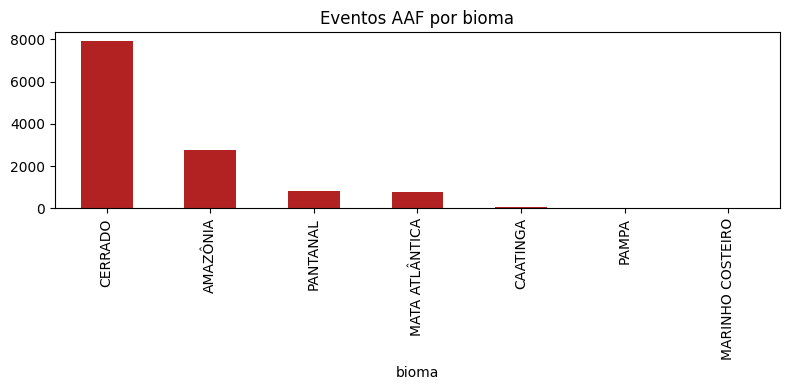

In [26]:
# Distribuição por bioma

print(gdf_aaf_metric['bioma'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
gdf_aaf_metric['bioma'].value_counts().plot(kind='bar', color='firebrick')
plt.title('Eventos AAF por bioma')
plt.tight_layout()
plt.show()

event_year
2011    1565
2012    1611
2013     953
2014    1370
2015    2088
2016    2025
2017    2677
2018    1509
2019    2161
2020    2487
2021    2130
2022    2758
2023    5220
2024    7436
2025    3082
2026    1873
Name: count, dtype: int64


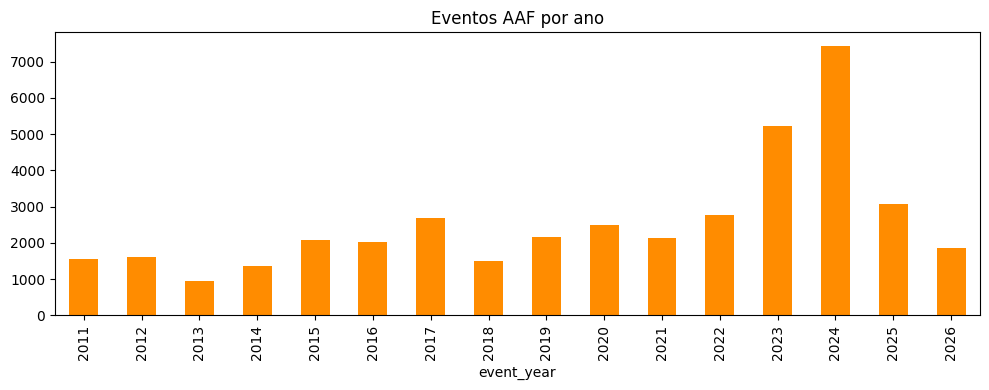

In [27]:
# Distribuição por ano

eventos_por_ano = gdf_aaf_metric['event_year'].value_counts().sort_index()
print(eventos_por_ano)

plt.figure(figsize=(10, 4))
eventos_por_ano.plot(kind='bar', color='darkorange')
plt.title('Eventos AAF por ano')
plt.tight_layout()
plt.show()

event_month
1.0      345
2.0      642
3.0     1051
4.0      899
5.0     3005
6.0     3737
7.0     5798
8.0     7806
9.0     9022
10.0    5489
11.0    2075
12.0    1076
Name: count, dtype: int64


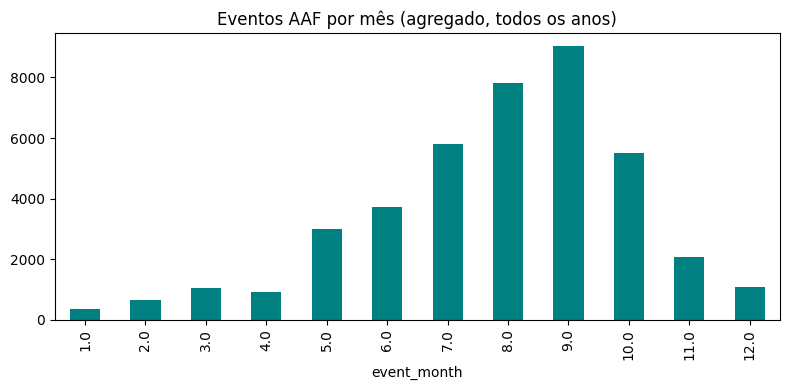

In [28]:
# Distribuição por mês (agregado, todos os anos)

eventos_por_mes = gdf_aaf_metric['event_month'].value_counts().sort_index()
print(eventos_por_mes)

plt.figure(figsize=(8, 4))
eventos_por_mes.plot(kind='bar', color='teal')
plt.title('Eventos AAF por mês (agregado, todos os anos)')
plt.tight_layout()
plt.show()

In [29]:
# Top 15 UCs com mais eventos registrados

print(gdf_aaf_metric['nome_uc'].value_counts().head(15))

nome_uc
PARNA do Araguaia                       6173
PARNA das Nascentes do Rio Parnaíba     5911
ESEC Serra Geral do Tocantins           4438
PARNA da Serra da Canastra              2211
PARNA da Chapada das Mesas              1509
FLONA do Jamanxim                       1375
ESEC de Uruçuí-Una                      1334
PARNA da Chapada dos Veadeiros          1249
PARNA do Pantanal Matogrossense         1245
PARNA dos Campos Amazônicos             1036
REBIO Nascentes da Serra do Cachimbo     611
RESEX Chico Mendes                       603
REVIS das Veredas do Oeste Baiano        590
REBIO do Guaporé                         583
FLONA do Bom Futuro                      538
Name: count, dtype: int64


In [30]:
# Categoria / ação / classe (colunas não uniformes entre eras do schema)

print("Categoria:\n", gdf_aaf_metric['categoria'].value_counts(dropna=False))
print("\nAção:\n", gdf_aaf_metric['acao'].value_counts(dropna=False))
print("\nClasse:\n", gdf_aaf_metric['classe'].value_counts(dropna=False))

Categoria:
 categoria
NaN          28554
combate       5847
manejo        3144
incendio      1811
prevenção     1589
Name: count, dtype: int64

Ação:
 acao
NaN                              35990
queima prescrita                  2485
incendio                          1811
queima controlada                  475
gestao de ignicao natural           55
aceiro                              53
gestao de ignicao antropica         45
queima por indigenas isolados       31
Name: count, dtype: int64

Classe:
 classe
incendio             15200
NaN                  11081
None                  9751
queima prescrita      3131
queima controlada     1184
indigena               291
fogo natural           156
outros                 104
aceiro                  46
raio                     1
Name: count, dtype: int64


In [31]:
# Distribuição por satélite usado na detecção

print(gdf_aaf_metric['satelite'].value_counts(dropna=False))

satelite
planet         20119
modis_terra    14108
modis_aqua      3660
sentinel_2      1585
landsat_8       1367
landsat_9         95
                   8
cbers_4            2
outros             1
Name: count, dtype: int64


count    34272.000000
mean       546.337381
std       1937.633548
min          0.000000
25%         35.867887
50%        136.210369
75%        399.523425
max      58780.900000
Name: area_ha, dtype: float64

Nulos em area_ha: 6673


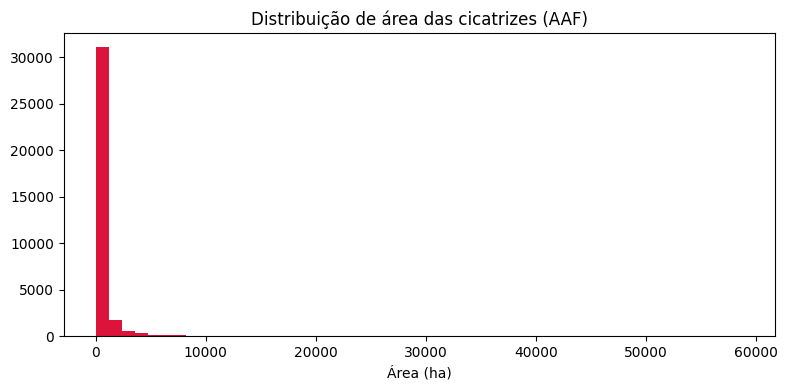

In [32]:
# Estatísticas de área (ha)

print(gdf_aaf_metric['area_ha'].describe())
print("\nNulos em area_ha:", gdf_aaf_metric['area_ha'].isna().sum())

plt.figure(figsize=(8, 4))
plt.hist(gdf_aaf_metric['area_ha'].dropna(), bins=50, color='crimson')
plt.xlabel('Área (ha)')
plt.title('Distribuição de área das cicatrizes (AAF)')
plt.tight_layout()
plt.show()

In [33]:
# Os maiores eventos registrados (top 10)

print(
    gdf_aaf_metric
    .nlargest(10, 'area_ha')
    [['nome_uc', 'event_year', 'event_date', 'area_ha', 'bioma']]
)

                                     nome_uc  event_year event_date       area_ha     bioma
21017  APA das Ilhas e Várzeas do Rio Paraná        2021 2021-12-30  58780.900000       NaN
36300                       REBIO do Guaporé        2024 2024-10-08  56931.982888  AMAZÔNIA
29129           APA Meandros do Rio Araguaia        2024 2024-09-13  56873.214083   CERRADO
35699            PARNA dos Campos Amazônicos        2024 2024-09-20  55580.247468  AMAZÔNIA
9570                          PARNA do Viruá        2016 2016-03-04  54917.820000       NaN
15468                      PARNA do Araguaia        2019 2019-09-07  53618.610000       NaN
35681                       FLONA de Carajás        2024 2024-09-22  52600.288463  AMAZÔNIA
5880           ESEC Serra Geral do Tocantins        2014 2014-09-01  51753.820000       NaN
14688                       FLONA de Roraima        2019 2019-04-07  50590.850000       NaN
3169           ESEC Serra Geral do Tocantins        2012 2012-09-20  50168.92000

## EDA — INPE (isolado, dentro de UC)

In [34]:
print("Total de focos dentro de UC:", len(gdf_inpe_with_cell))
print("\nColunas disponíveis:\n", gdf_inpe_with_cell.columns.tolist())

Total de focos dentro de UC: 2565609

Colunas disponíveis:
 ['latitude', 'longitude', 'data_pas', 'satelite', 'pais', 'estado', 'municipio', 'bioma', 'numero_dias_sem_chuva', 'precipitacao', 'risco_fogo', 'id_area_industrial', 'frp', 'file_year', 'geometry', 'index_right', 'cell_id']


In [35]:
# Corrigir valor sentinela -999 (código de "sem dado", não um valor real)

print("Valores == -999 em risco_fogo:", (gdf_inpe_with_cell['risco_fogo'] == -999).sum())
print("Valores == -999 em numero_dias_sem_chuva:", (gdf_inpe_with_cell['numero_dias_sem_chuva'] == -999).sum())

sentinela_por_satelite = (
    gdf_inpe_with_cell[gdf_inpe_with_cell['risco_fogo'] == -999]
    ['satelite'].value_counts()
)
print("\nSatélites com valor sentinela -999 em risco_fogo:\n", sentinela_por_satelite)

gdf_inpe_with_cell['risco_fogo'] = gdf_inpe_with_cell['risco_fogo'].replace(-999, np.nan)
gdf_inpe_with_cell['numero_dias_sem_chuva'] = gdf_inpe_with_cell['numero_dias_sem_chuva'].replace(-999, np.nan)


Valores == -999 em risco_fogo: 38654
Valores == -999 em numero_dias_sem_chuva: 21336

Satélites com valor sentinela -999 em risco_fogo:
 satelite
GOES-16      15265
NOAA-20       6578
NPP-375       4859
NPP-375D      4412
NOAA-21       2487
METOP-B        858
NOAA-19        743
METOP-C        609
AQUA_M-T       566
TERRA_M-T      384
NOAA-18D       377
GOES-13        345
MSG-03         279
NOAA-19D       260
NOAA-18        205
TERRA_M-M      167
AQUA_M-M       106
GOES-19        104
NOAA-15         40
NOAA-16N         5
NOAA-16          2
NOAA-15D         2
TRMM             1
Name: count, dtype: int64


bioma
Amazônia          1056688
Cerrado            974864
Caatinga           234492
Pantanal           149080
Mata Atlântica     147237
Pampa                3245
NaN                     3
Name: count, dtype: int64


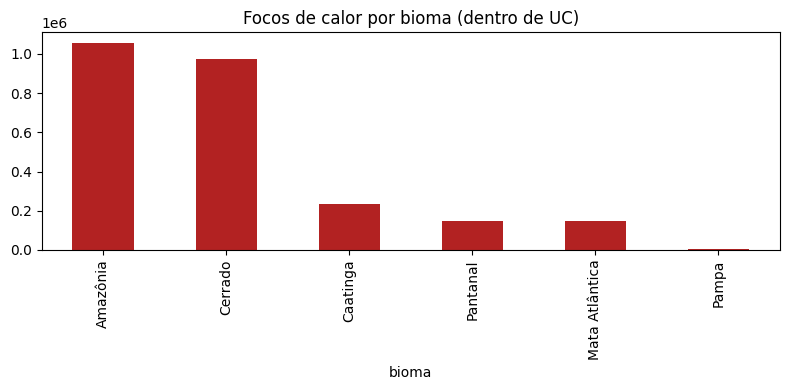

In [36]:
# Distribuição por bioma

print(gdf_inpe_with_cell['bioma'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
gdf_inpe_with_cell['bioma'].value_counts().plot(kind='bar', color='firebrick')
plt.title('Focos de calor por bioma (dentro de UC)')
plt.tight_layout()
plt.show()

file_year
2003     28832
2004     34550
2005     33112
2006     23398
2007     37999
2008     21453
2009     12706
2010     47037
2011     21082
2012    113074
2013     47890
2014     81031
2015    111995
2016     88283
2017    122345
2018     58602
2019    185403
2020    249510
2021    192339
2022    199545
2023    200893
2024    523641
2025    130889
Name: count, dtype: int64


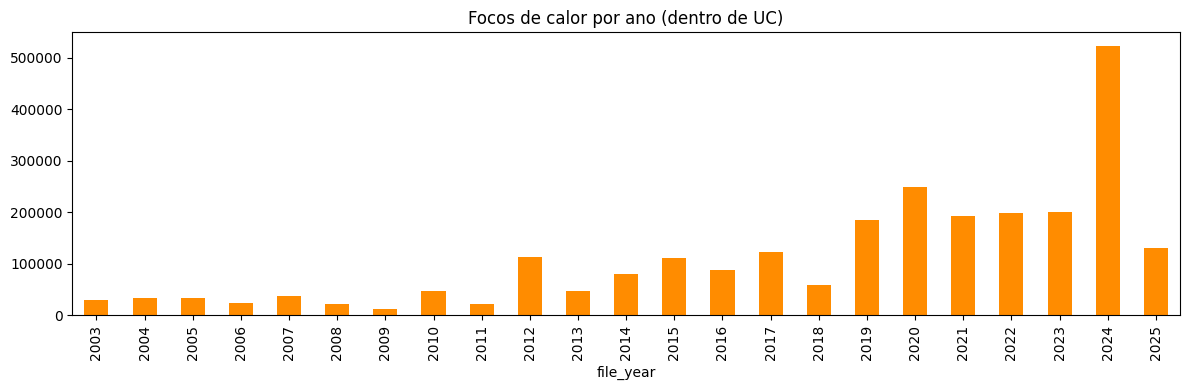

In [37]:
# Distribuição por ano

focos_por_ano = gdf_inpe_with_cell['file_year'].value_counts().sort_index()
print(focos_por_ano)

plt.figure(figsize=(12, 4))
focos_por_ano.plot(kind='bar', color='darkorange')
plt.title('Focos de calor por ano (dentro de UC)')
plt.tight_layout()
plt.show()


mes
1      39714
2      18597
3      31955
4      17246
5      34537
6      60809
7     146000
8     658997
9     759004
10    418980
11    249095
12    130675
Name: count, dtype: int64


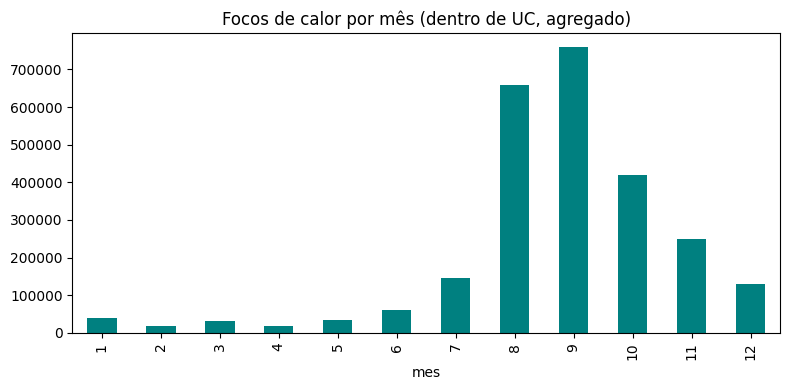

In [38]:
# Distribuição por mês (agregado, todos os anos)

gdf_inpe_with_cell['data_pas'] = pd.to_datetime(gdf_inpe_with_cell['data_pas'], errors='coerce')
gdf_inpe_with_cell['mes'] = gdf_inpe_with_cell['data_pas'].dt.month

focos_por_mes = gdf_inpe_with_cell['mes'].value_counts().sort_index()
print(focos_por_mes)

plt.figure(figsize=(8, 4))
focos_por_mes.plot(kind='bar', color='teal')
plt.title('Focos de calor por mês (dentro de UC, agregado)')
plt.tight_layout()
plt.show()


In [39]:
# Distribuição por satélite

print(gdf_inpe_with_cell['satelite'].value_counts(dropna=False))

satelite
NPP-375      574654
NOAA-20      451723
GOES-16      431813
NPP-375D     247827
AQUA_M-T     211676
NOAA-21      153593
TERRA_M-T     82193
TERRA_M-M     46497
NOAA-19       42626
GOES-12       41460
GOES-13       27056
NOAA-18       26986
GOES-19       26197
METOP-B       26106
NOAA-15       25247
AQUA_M-M      24839
NOAA-12       23196
MSG-03        17660
NOAA-16       17608
METOP-C       15101
NOAA-18D      13195
MSG-02         9226
NOAA-19D       8348
GOES-10        7820
TRMM           3745
ATSR           2753
NOAA-16N       2202
NOAA-17        1676
NOAA-15D       1264
NOAA-14         820
NOAA-12D        411
GOES-08          91
Name: count, dtype: int64


In [40]:
# Top 15 UCs com mais focos (equivalente ao "município" do dado nacional, aqui usamos a UC)

focos_com_uc = gpd.sjoin(
    gdf_inpe_with_cell[['satelite', 'frp', 'data_pas', 'geometry']],
    gdf_ucs_metric[['cnuc', 'nomeuc', 'geometry']],
    how='left',
    predicate='within'
)
print(focos_com_uc['nomeuc'].value_counts().head(15))

nomeuc
PARQUE NACIONAL DO ARAGUAIA                                     288463
FLORESTA NACIONAL DO JAMANXIM                                   231814
PARQUE NACIONAL DAS NASCENTES DO RIO PARNAÍBA                   152294
PARQUE NACIONAL DO PANTANAL MATO-GROSSENSE                      127081
ESTAÇÃO ECOLÓGICA SERRA GERAL DO TOCANTINS                      119589
ÁREA DE PROTEÇÃO AMBIENTAL SERRA DA IBIAPABA                    118498
ÁREA DE PROTEÇÃO AMBIENTAL DAS ILHAS E VÁRZEAS DO RIO PARANÁ     95980
RESERVA EXTRATIVISTA CHICO MENDES                                94753
ÁREA DE PROTEÇÃO AMBIENTAL DO TAPAJÓS                            79716
ÁREA DE PROTEÇÃO AMBIENTAL DOS MEANDROS DO RIO ARAGUAIA          76621
ÁREA DE PROTEÇÃO AMBIENTAL DA CHAPADA DO ARARIPE                 72914
ÁREA DE PROTEÇÃO AMBIENTAL DO PLANALTO CENTRAL                   61488
RESERVA EXTRATIVISTA VERDE PARA SEMPRE                           49355
RESERVA BIOLÓGICA NASCENTES DA SERRA DO CACHIMBO                 48149

count    1.574279e+06
mean     3.704171e+01
std      7.641132e+01
min     -2.100000e+01
25%      4.900000e+00
50%      1.210000e+01
75%      4.300000e+01
max      9.783900e+03
Name: frp, dtype: float64

Nulos em frp: 991330 (38.6%)


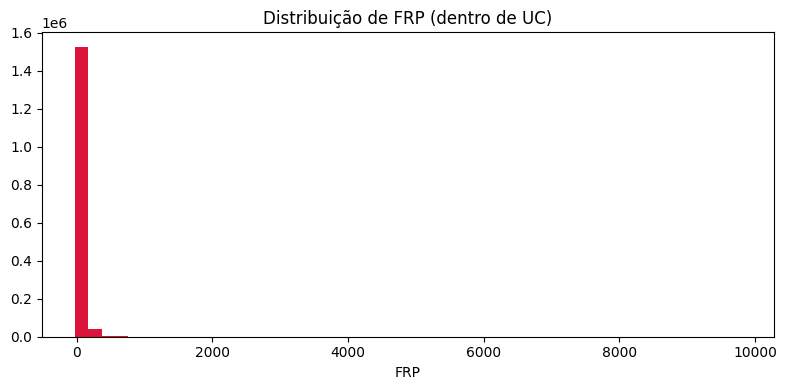

In [41]:
# FRP — estatísticas gerais (dentro de UC)

print(gdf_inpe_with_cell['frp'].describe())
print("\nNulos em frp:", gdf_inpe_with_cell['frp'].isna().sum(),
      f"({gdf_inpe_with_cell['frp'].isna().sum()/len(gdf_inpe_with_cell)*100:.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(gdf_inpe_with_cell['frp'].dropna(), bins=50, color='crimson')
plt.xlabel('FRP')
plt.title('Distribuição de FRP (dentro de UC)')
plt.tight_layout()
plt.show()

In [42]:
# FRP por satélite — estatísticas e % de nulo

frp_by_satellite = gdf_inpe_with_cell.groupby('satelite')['frp'].agg(
    total='count',
    media='mean',
    mediana='median',
    minimo='min',
    maximo='max'
)

total_por_satelite = gdf_inpe_with_cell['satelite'].value_counts()
pct_nulo_por_satelite = gdf_inpe_with_cell.groupby('satelite')['frp'].apply(
    lambda x: x.isna().mean() * 100
)

frp_by_satellite['total_registros'] = total_por_satelite
frp_by_satellite['pct_nulo'] = pct_nulo_por_satelite

print(frp_by_satellite.sort_values('total_registros', ascending=False))

            total       media  mediana  minimo  maximo  total_registros    pct_nulo
satelite                                                                           
NPP-375    338429   17.194280      9.1     0.0  1993.3           574654   41.107345
NOAA-20    342190   12.870046      6.3     0.0  1286.0           451723   24.247824
GOES-16    201742  110.275275     88.9    14.2  2301.1           431813   53.280239
NPP-375D   147249    3.801033      1.9     0.0  1083.9           247827   40.583956
AQUA_M-T   211437   61.798802     29.9   -21.0  4305.4           211676    0.112908
NOAA-21    153593   14.664218      7.0    -0.2  1748.7           153593    0.000000
TERRA_M-T   82178   54.666434     26.1     0.0  9783.9            82193    0.018250
TERRA_M-M   46443   30.964718     14.8     0.0  3112.2            46497    0.116137
NOAA-19         0         NaN      NaN     NaN     NaN            42626  100.000000
GOES-12         0         NaN      NaN     NaN     NaN            41460  100

In [43]:
# Estatísticas de risco_fogo e numero_dias_sem_chuva (já sem o sentinela -999)

print("Risco de fogo:\n", gdf_inpe_with_cell['risco_fogo'].describe())
print("\nNulos em risco_fogo:", gdf_inpe_with_cell['risco_fogo'].isna().sum())

print("\nDias sem chuva:\n", gdf_inpe_with_cell['numero_dias_sem_chuva'].describe())
print("\nNulos em numero_dias_sem_chuva:", gdf_inpe_with_cell['numero_dias_sem_chuva'].isna().sum())

Risco de fogo:
 count    2.090697e+06
mean     7.983380e-01
std      3.162120e-01
min      0.000000e+00
25%      7.000000e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: risco_fogo, dtype: float64

Nulos em risco_fogo: 474912

Dias sem chuva:
 count    2.108015e+06
mean     2.546665e+01
std      3.433019e+01
min      0.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      3.300000e+01
max      7.940000e+02
Name: numero_dias_sem_chuva, dtype: float64

Nulos em numero_dias_sem_chuva: 457594


In [44]:
# Os focos de maior FRP registrados dentro de UC (top 10)

print(
    gdf_inpe_with_cell
    .nlargest(10, 'frp')
    [['cell_id', 'bioma', 'data_pas', 'satelite', 'frp']]
)

          cell_id     bioma            data_pas   satelite     frp
6735302   462_348   Cerrado 2010-08-13 14:27:00  TERRA_M-T  9783.9
6735274   463_353   Cerrado 2010-08-13 14:27:00  TERRA_M-T  9744.5
33296180  463_351   Cerrado 2021-07-10 14:25:00  TERRA_M-T  5860.0
6735273   463_353   Cerrado 2010-08-13 14:27:00  TERRA_M-T  5626.5
6735263   463_352   Cerrado 2010-08-13 14:27:00  TERRA_M-T  5187.4
6735367   463_352   Cerrado 2010-08-13 14:27:00  TERRA_M-T  4927.5
6735281   464_352   Cerrado 2010-08-13 14:27:00  TERRA_M-T  4882.8
2672935   404_567  Amazônia 2005-08-04 14:43:00  TERRA_M-T  4602.1
33296169  463_350   Cerrado 2021-07-10 14:25:00  TERRA_M-T  4558.7
6735331   463_353   Cerrado 2010-08-13 14:27:00  TERRA_M-T  4509.1


# Pré-processamento

# Modelagem / treinamento

# Avaliação do modelo

# Ajuste de hiperparâmetros

# Validação final